In [1]:
import os
import fitz


from supabase.client import Client, create_client
from langchain_groq import ChatGroq 
from sentence_transformers import SentenceTransformer

from langgraph.graph import StateGraph,START, END
from pydantic import BaseModel, Field # for defining structured output for models
import operator

from typing import List, TypedDict, Literal, Annotated, Optional
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain.chains import RetrievalQA

from langchain_core.messages import SystemMessage, HumanMessage


import warnings
warnings.filterwarnings('ignore')

C:\Users\niazm\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

## process the UOS student handbook 2025-2026 from Top Level Agent

In [3]:
def bookPdfDataProcessor(BookPath): 
    uoshandBook = fitz.open(BookPath)

    Book_contentInner = []
    page_contentInnder = ""

    for page_num, page in enumerate(uoshandBook):
        blocks = page.get_text("blocks")

        for block in blocks:         
            tempCont = block[4].replace("\n", "")
            tempCont = tempCont.replace("\t", " ")
            tempCont = tempCont.replace("\xad", " ") 
            page_contentInnder = page_contentInnder + tempCont

            if len(page_contentInnder.split(" "))>250: 
                Book_contentInner.append(page_contentInnder)
                page_contentInnder = ""

    if len(page_contentInnder.split(" "))>50:
        Book_contentInner.append(page_contentInnder)
        page_contentInnder = ""

    return Book_contentInner


Book_content = bookPdfDataProcessor("./UOS Faculty Handbook 25-26 Design.pdf") + bookPdfDataProcessor("./Student Handbook.pdf")
    
print(min([len(x.split(" ")) for x in Book_content]), max([len(x.split(" ")) for x in Book_content]), sum([len(x.split(" ")) for x in Book_content])/len([len(x.split(" ")) for x in Book_content]))

139 715 299.55280898876407


### Now tokenize these texts and create a vector DB to store them

In [4]:
topLevelAgent_QNA_vectorStore = FAISS.from_texts(Book_content, embeddings)
topLevelAgent_QNA_retriver = topLevelAgent_QNA_vectorStore.as_retriever(search_kwargs={"k":10})

In [5]:
qa_chain_cs_docs = topLevelAgent_QNA_retriver.get_relevant_documents("what department are in College of computing and informatics? ")
# qa_chain_cs_docs = "\n\n".join([d.page_content for d in qa_chain_cs_docs])

qa_chain_cs_docs_modSnet = []
for sent in qa_chain_cs_docs: 
    for word in sent.page_content.split(" "): 
        if word == " " or word=="\t": 
            continue
        else: 
            qa_chain_cs_docs_modSnet.append(word)
        if len(qa_chain_cs_docs_modSnet)>2000: 
            break


qa_chain_cs_docs = " ".join(qa_chain_cs_docs_modSnet)
print(len(qa_chain_cs_docs.split(" ")))

2004


## define the state for the model

In [6]:
class UOS_AgentState(BaseModel): 
    uid: str
    mensOrWomCampus: Literal['mens', 'womens']
    standing: Literal["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
    yearOfStudy: Literal[1,2,3,4,5]
    semester: Literal[1,2,3,4,5,6,7,8,9,10]
    college: Literal[
        "College of Science", 
        "College of Computing and Informatics"
    ]
    department: Literal[
        "BSc_Mathematics", 
        "BSc_Chemistry", 
        "BSc_Petroleum_Geosciences_and_Remote_Sensing", 
        "BSc_Biotechnology", 
        "BSc_Business_Information_Systems", 
        "BSc_IT_Multimedia", 
        "BSc_Computer_Science", 
        "BSc_Cybersecurity", 
        "BSc_Computer_Engineering"
    ]
    studentAlreadyCompletedCourses : List[str] =[]
    StudentAlreadyCompletedCredits : int = 0

    student_query : str

    # agent decision states: below None is for just for redundancy
    UOS_AgentState_top_level_decision: Literal["ScienceAgent", "CCIAgent"] = None
    UOS_AgentState_CCIAgent_decision: Literal["Basic_CCI_Conversation", "CCI_course_related_conversation", "CCI_CourseScheduling_advising"] = None
    UOS_AgentState_ScienceAgent_decision: Literal["Basic_Science_Conversation", "Science_course_related_conversation", "Science_CourseScheduling_advising"] = None

    # Status update based on agent response
    topLevelAgent_basicConversationOrNot: bool = None
    basic_Conversation_answer : str = None

### define the structured schemas 

In [7]:
class UOS_AgentState_top_level(BaseModel):
    basicConversationOrNot: bool = Field(
        description="True if the student is engaging in general basic conversation, False if the user is asking about academic advising"
    )
    academicAdvising: Optional[Literal["ScienceAgent", "CCIAgent"]] = Field(
        description="ScienceAgent if the user is from College of Science, CCIAgent if the user is from College of Computing and Informatics. Null if not applicable."
    )


class UOS_AgentState_CCI(BaseModel):
    conditionalStateGetter: Optional[Literal[
        "Basic_CCI_Conversation",
        "CCI_course_related_conversation",
        "CCI_CourseScheduling_advising"
    ]] = Field(
        ...,
        description=(
            "'Basic_CCI_Conversation' if the student is engaging in general basic conversation "
            "about the College of Computing and Informatics. "
            "If the student asks about specific CCI courses such as: "
            "'Minor in Data Analytics', 'B.Sc in Business Information Systems', "
            "'Minor in AI', 'B.Sc in Biomedical Informatics', "
            "'B.Sc in Computer Science', 'B.Sc in Information Technology Multimedia', "
            "'B.Sc in Cybersecurity Engineering', 'B.Sc in Computer Engineering', "
            "'Minor in Cybersecurity' → return 'CCI_course_related_conversation'. "
            "If the student is asking about course scheduling or academic advising for this semester "
            "→ return 'CCI_CourseScheduling_advising'."
        )
    )


class UOS_AgentState_Science(BaseModel):
    conditionalStateGetter: Optional[Literal[
        "Basic_Science_Conversation",
        "Science_course_related_conversation",
        "Science_CourseScheduling_advising"
    ]] = Field(
        ...,
        description=(
            "'Basic_Science_Conversation' if the student is engaging in general basic conversation "
            "about the College of Science. "
            "If the student asks about specific Science courses such as: "
            "'B.Sc in Mathematics', 'B.Sc in Chemistry', "
            "'B.Sc in Petroleum Geosciences and Remote Sensing', "
            "'B.Sc in Applied Physics', 'B.Sc in Biotechnology' "
            "→ return 'Science_course_related_conversation'. "
            "If the student is asking about course scheduling or academic advising for this semester "
            "→ return 'Science_CourseScheduling_advising'."
        )
    )

In [ ]:
groq_api_key = "Your groq api key here"

generator_llm = ChatGroq(
    api_key = groq_api_key, 
    model_name = "qwen/qwen3-32b",
    temperature = 0,
    max_completion_tokens = 512,
    top_p = 1.0,
    stream = False,
    stop = None,
    include_reasoning  = False
)

## make the model structured
top_level_llm = generator_llm.with_structured_output(UOS_AgentState_top_level)
CCI_LLM = generator_llm.with_structured_output(UOS_AgentState_CCI)
Science_LLM = generator_llm.with_structured_output(UOS_AgentState_Science)

### Now define the fuction that calls LLM on prompt and "Updates state"

In [9]:
def topLevelLLM_call(state: UOS_AgentState): 
    # process with structured top level LLM
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for University of Sharjah. "
            "You will help students for there basic/general Queries "
            "You will also engage in general basic conversation with students. "
            "Always respond in a friendly and professional manner."
            "The department in College of Science are: Department of Applied Biology offers B.Sc in Biotechnology | Department of Chemistry offers B.Sc in Chemistry | Department of Mathematics offers B.Sc in Mathematics | Department of Applied Physics and Astronomy offers B.Sc in Petroleum Geosciences and Remote Sensing and B.Sc in Applied Physics "
            "The department in College of Computing and Informatics are: Department of Computer Engineering  offers B.Sc in Computer Engineering and B.Sc in Cybersecurity Engineering | Department of Computer Science offers B.Sc in Computer Science, B.Sc in Information Technology Multimedia, B.SC in Biomedical Informatics | Department of Information Systems offers B.Sc in Business Information Systems and Minor in Data Analytics |"
        )),
        HumanMessage(content=(
            f"The student is from {state.college} and is in their {state.standing} year of study. "
            f"The student has completed the following courses: {', '.join(state.studentAlreadyCompletedCourses)}. "
            f"The student has completed {state.StudentAlreadyCompletedCredits} credits so far. "
            f"The student is currently on the {state.mensOrWomCampus} campus. "
            f"The student is asking: {state.student_query}. "
            "Based on this information, determine if the student is engaging in general basic conversation related to College of Computing and informatics or College of Science"
            "or if they are asking about academic advising. "
            "If it's a basic conversation, respond with 'basicConversationOrNot' as True and provide a brief "
            "summary in 'generalBasicConversation'. "
            "If it's about academic advising, respond with 'basicConversationOrNot' as False and specify which "
            "agent should handle the request in 'academicAdvising' (either 'ScienceAgent' or 'CCIAgent'). "
            "If you don't have knowledge on the topic, set 'basicConversationOrNot' to True with a summary."
        ))
    ]

    response = top_level_llm.invoke(messages)
    if response.basicConversationOrNot == True: 
        return {'topLevelAgent_basicConversationOrNot': True} # then end the conversation 

    return {'topLevelAgent_basicConversationOrNot': False , 'UOS_AgentState_top_level_decision': response.academicAdvising}

In [10]:
def CCI_LLM_call(state: UOS_AgentState):
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for 'College of Computing and Informatics' in University of Sharjah. "
            "You will help students with their academic advising and course scheduling. "
            "You will also engage in general basic conversation with students. "
            "Always respond in a friendly and professional manner."
            "The department in College of Computing and Informatics are: Department of Computer Engineering  offers B.Sc in Computer Engineering and B.Sc in Cybersecurity Engineering | Department of Computer Science offers B.Sc in Computer Science, B.Sc in Information Technology Multimedia, B.SC in Biomedical Informatics | Department of Information Systems offers B.Sc in Business Information Systems and Minor in Data Analytics |"
        )),
         HumanMessage(content=(
            f"The student is asking: {state.student_query}. "
            "Based on this information, determine if the student is engaging in general basic conversation "
            "or if they are asking about academic advising. "
            "If it's a basic conversation, return 'Basic_CCI_Conversation' "
            "Or else if stundent ask about anything related to course then return 'CCI_course_related_conversation'"
            "If it's about academic advising, return with 'CCI_CourseScheduling_advising'"
        ))    
    ]

    response = CCI_LLM.invoke(messages)
    print("response from CCI:" , response)
    return {'UOS_AgentState_CCIAgent_decision': response.conditionalStateGetter}

In [11]:
def Science_LLM_call(state: UOS_AgentState):
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for 'College of Science' in University of Sharjah. "
            "You will help students with their academic advising and course scheduling. "
            "You will also engage in general basic conversation with students. "
            "Always respond in a friendly and professional manner."
            "The department in College of Science are: Department of Applied Biology offers B.Sc in Biotechnology | Department of Chemistry offers B.Sc in Chemistry | Department of Mathematics offers B.Sc in Mathematics | Department of Applied Physics and Astronomy offers B.Sc in Petroleum Geosciences and Remote Sensing and B.Sc in Applied Physics "
        )),
        HumanMessage(content=(
            f"The student is asking: {state.student_query}. "
            "Based on this information, determine if the student is engaging in general basic conversation "
            "or if they are asking about academic advising. "
            "If it's a basic conversation, return 'Basic_Science_Conversation' "
            "Or else if stundent ask about anything related to course then return 'Science_course_related_conversation'"
            "If it's about academic advising, return with 'CCI_CourseScheduling_aScience_CourseScheduling_advisingdvising'"
        ))    
    ]

    response = Science_LLM.invoke(messages)
    return {'UOS_AgentState_ScienceAgent_decision': response.conditionalStateGetter}

### top-level agent: if the conversation is basic then relocate the Top-Level agen to get answer from vectorized Book Data

In [ ]:
def topLevel_agent_RAG(state: UOS_AgentState):
    # toplevelAgent -> 
    qa_chain_retrived_docs = topLevelAgent_QNA_retriver.get_relevant_documents(state.student_query)
    qa_chain_docs_2000 = []

    for sent in qa_chain_retrived_docs: 
        for word in sent.page_content.split(" "): 
            if word == " " or word=="\t": 
                continue
            else: 
                qa_chain_docs_2000.append(word)
            if len(qa_chain_docs_2000)>2000: 
                break

    qa_chain_retrived_docs = " ".join(qa_chain_docs_2000)
    
    # now re-structure the texts using LLM model
    messages = [
        SystemMessage(content=(
            "You are an academic advisor agent for the University of Sharjah. "
            "Do NOT include <think> tags or reasoning traces. "
            "Only give the final structured answer directly, in human-readable form."
        )),
        HumanMessage(content=(
            f"Student Question: {state.student_query}\n"
            f"Retrieved texts: {qa_chain_retrived_docs}"
        ))
    ]

    # basic_Conversation_answer
    responsed_structuredLLM_texts = generator_llm.invoke(messages)

    return {
        "basic_Conversation_answer": responsed_structuredLLM_texts.content 
    }

### Now work for CCI college 3 part: Basic_qna

In [ ]:
## Course and other link for CCI 
cci_basicQna_link = {
    "B_Sc_Computer_Engineering": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Computer-Engineering" ,
    "B_Sc_Cybersecurity_Engineering": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Cybersecurity-Engineering" ,

    "B_Sc_Information_Technology_Multimedia": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Information-Technology-Multimedia", 
    "B_Sc_Computer_Science": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Computer-Science", 
    "B_Sc_Biomedical_Informatics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Biomedical-Informatics", 
    "B_Sc_Minor_in_AI": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Minor-in-AI",

    "B_Sc_Business_Information_system": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Information-Systems"
}
cci_basicQna_Offered_Courses = {
    "Department_of_Computer_Engineering": "Department of Computer Engineering Offers 2 courses for Bachelor in Science. 1.B.Sc in Computer_Engineering and 2.B.Sc in Cybersecurity_Engineering",
    "Department_of_Computer_Science": "Department of Computer Science offeres 4 courses for Bachelor in Science. 1.B.Sc in Information Technology Multimedia , 2.B.Sc Computer Science, 3.B.Sc Biomedical Informatics, 4.B.Sc in Minor in AI",
    "Department_of_Information_system": "Departent of Information system provides one course for B.Sc levele:  B.Sc in Business Information system"
}

## Course and other link for Science college
science_basicQna_link = {
    "B_Sc_Bio_Technology": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Biotechnology", 
    "B_Sc_Petroleum_Geoscience_and_Remote_Sensing": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Petroleum-Geosciences-and-Remote-Sensing", 
    "B_Sc_Applied_Physics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Applied-Physics", 

    "B_Sc_Chemistry": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Chemistry", 
    "B_Sc_MatheMatics": "https://www.sharjah.ac.ae/en/Academics/Degree/Undergraduate/Mathematics"
}
science_basicQna_Offered_Courses = {
    "Department_of_Applied_Biology": "provies one course in B.Sc : B.Sc in Bio-technology", 
    "Department_of_Applied_Physics_and_Astronomy": "Provides 2 course in B.Sc: Bachelor of Science in Petroleum Geosciences and Remote Sensing, Bachelor of Science in Applied Physics",
    "Department_of_Chemistry": "Privices 1 course for B.Sc: Bachelor of Science in Chemistry", 
    "Department_of_Mathematics": "Privides 1 course for B.Sc: Bachelor of Science in Mathematics"
}

### add conditional statement for splitting nodes: ======================

In [13]:
def routting_model(state: UOS_AgentState): 
    if state.topLevelAgent_basicConversationOrNot == False and state.UOS_AgentState_top_level_decision == "CCIAgent": 
        return "CCIAgent_Route"
    elif state.topLevelAgent_basicConversationOrNot == False and state.UOS_AgentState_top_level_decision == "ScienceAgent":
        return "ScienceAgent_Route"
    else: 
        return "topLevel_agent_rag_workflow"

### define the Nodes and Edges and Connect them

In [14]:
graph = StateGraph(UOS_AgentState)


graph.add_node('uosTopAgent', topLevelLLM_call)
graph.add_node('uosTopAgent_Basic_QNA_RAG', topLevel_agent_RAG)
graph.add_node('uosCCIAgent', CCI_LLM_call)
graph.add_node('uosScienceAgent', Science_LLM_call)

# define edges
graph.add_edge(START, 'uosTopAgent')
graph.add_conditional_edges('uosTopAgent', routting_model , {'CCIAgent_Route': 'uosCCIAgent', 'ScienceAgent_Route': 'uosScienceAgent', 'topLevel_agent_rag_workflow': 'uosTopAgent_Basic_QNA_RAG'})

graph.add_edge('uosTopAgent_Basic_QNA_RAG', END)
graph.add_edge('uosCCIAgent', END)
graph.add_edge('uosScienceAgent', END)

# compile the graph
mainWorkingGaph = graph.compile()

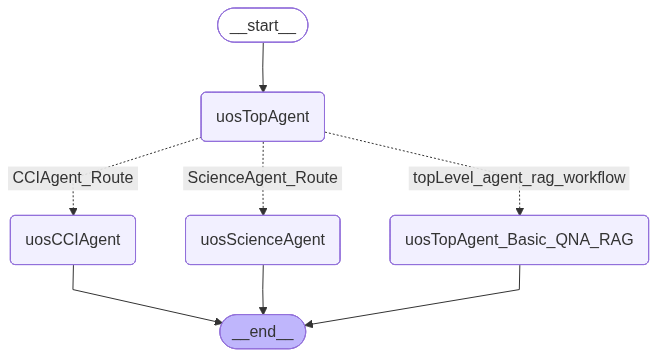

In [15]:
mainWorkingGaph

### Now do some dummy call

In [18]:
initial_state = {
    "uid": "U22106802", 
    "mensOrWomCampus" : "mens",
    "standing": "Senior",
    "semester": 7,
    "yearOfStudy": 4,
    "college": "College of Computing and Informatics", 
    "department" : "BSc_Computer_Science",
    "studentAlreadyCompletedCourses": [
        "1420-101", "1420-102", "1430-110",	"1430-116",
        "1440-131","1501-116","1501-211",
        "1501-215","1501-246","1501-250","1501-252",
        "1501-279","1501-371","1501-394","1501-454",
        "1501-341","1501-465","1440-211","1440-281",
        "0104-100","0302-200","1501-100","0302-150","0401-142"
    ],
    "StudentAlreadyCompletedCredits" : 72,
    #"student_query": "How many credits do I need to graduate if I am majoring in Bio-technology?",
    "student_query": "How many credits do I need to graduate if I am majoring in Computer Science?",
    #"student_query": "Can you register 5 courses offerd by university this semester for me? ",
    #"student_query": "How many colleges are there in university of sharjah?",
}

result = mainWorkingGaph.invoke(initial_state)
display(result)

response from CCI: conditionalStateGetter='CCI_course_related_conversation'


{'uid': 'U22106802',
 'mensOrWomCampus': 'mens',
 'standing': 'Senior',
 'yearOfStudy': 4,
 'semester': 7,
 'college': 'College of Computing and Informatics',
 'department': 'BSc_Computer_Science',
 'studentAlreadyCompletedCourses': ['1420-101',
  '1420-102',
  '1430-110',
  '1430-116',
  '1440-131',
  '1501-116',
  '1501-211',
  '1501-215',
  '1501-246',
  '1501-250',
  '1501-252',
  '1501-279',
  '1501-371',
  '1501-394',
  '1501-454',
  '1501-341',
  '1501-465',
  '1440-211',
  '1440-281',
  '0104-100',
  '0302-200',
  '1501-100',
  '0302-150',
  '0401-142'],
 'StudentAlreadyCompletedCredits': 72,
 'student_query': 'How many credits do I need to graduate if I am majoring in Computer Science?',
 'UOS_AgentState_top_level_decision': 'CCIAgent',
 'UOS_AgentState_CCIAgent_decision': 'CCI_course_related_conversation',
 'topLevelAgent_basicConversationOrNot': False}